# 54 · A principled tour of the signals

Goal: build up, carefully and with fixed notation, what our six basic spectral signals are and what each one shows — first **averaged over lasers and channels** (Part A), then **in full per-laser detail** (Part B). Everything in this notebook is for **one speaker**, set once in the config cell below, and every figure shows the **3 recordings of the same scene side by side** — so any structure that is *real* must appear in all three columns.

## Notation

$s_{n,c}(t)$ — the tracked speckle-shift time series of laser $n \in \{0,\dots,99\}$ and shift channel $c \in \{x, y\}$, sampled at $F_s = 2500$ Hz for ~3 s. Its FFT is $F_{n,c}(f) = \mathrm{FFT}\!\left[s_{n,c}\right](f)$ (complex), on a fine $\Delta f \approx 0.34$ Hz grid, kept in 50–1000 Hz.

| # | signal | formula | grid | units |
|---|---|---|---|---|
| 1 | **FFT magnitude** | $\lvert F_{n,c}(f)\rvert$ | 0.34 Hz | px |
| 2 | **power** | $\lvert F_{n,c}(f)\rvert^2$ | 0.34 Hz | px² |
| 3 | **PSD (Welch)** | $\hat S_{n,c}(f)$: the capture is cut into 11 half-overlapping 0.5 s Hann windows, each is FFT'd, and the 11 $\lvert\mathrm{FFT}\rvert^2$ are averaged and normalized per Hz | 2 Hz | px²/Hz |
| 4 | **log FFT magnitude** | $\log_{10}\lvert F_{n,c}(f)\rvert$ | 0.34 Hz | — |
| 5 | **log power** | $\log_{10}\lvert F_{n,c}(f)\rvert^2 = 2\log_{10}\lvert F_{n,c}(f)\rvert$ | 0.34 Hz | — |
| 6 | **log PSD** | $\log_{10}\hat S_{n,c}(f)$ | 2 Hz | — |

How they relate:

- **power is magnitude squared** — same information, different emphasis: squaring stretches the top of the scale and crushes the bottom.
- **PSD is power, averaged over 11 time segments and normalized per Hz** — it trades frequency resolution (0.34 → 2 Hz) for ~11× less single-bin estimator variance: the *smooth, statistically honest* version of the same curve.
- **the log trio are all the same curve up to scale and offset**: log power = 2 × log magnitude exactly, and log PSD is its segment-averaged cousin (dB is just 10·log₁₀ PSD or 20·log₁₀ magnitude). Log is also the physically right space: the forward model's nuisance factors are multiplicative, so in log they become additive offsets.

$\langle\,\cdot\,\rangle_{n,c}$ denotes the average over all 100 lasers and both channels.


In [2]:
import sys
from pathlib import Path

def _find_repo_root(marker='pyproject.toml'):
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / marker).exists(): return candidate
    raise RuntimeError('repo root not found')

REPO_ROOT = _find_repo_root()
for p in (REPO_ROOT, REPO_ROOT / 'src'):
    if str(p) not in sys.path: sys.path.insert(0, str(p))

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sps

from utils.io_utils import load

# ---------------- config: this whole notebook is about ONE speaker ----------------
SPEAKER = 1        # <- change me and rerun

# SAMPLES_DIR = Path(r'D:\eturok\experiment-25\samples'); OUTPUTS = [0, 1, 2]
SAMPLES_DIR = Path(r'D:\eturok\experiment-24\samples'); OUTPUTS = [96, 97, 98]
# -----------------------------------------------------------------------------------

FS, NPERSEG = 2500, 1250       # Welch: 0.5 s Hann segments, 50% overlap -> 11 segments, 2 Hz grid
OUT_COLORS = {o: c for o, c in zip(OUTPUTS, ['#0072B2', '#E69F00', '#009E73'])}  # Okabe-Ito, fixed per recording
plt.rcParams.update({'figure.dpi': 80, 'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.25})

F, PSD = {}, {}                # F[out]: complex FFT (lasers, fft bins, channels); PSD[out]: (lasers, channels, welch bins)
for out in OUTPUTS:
    d = SAMPLES_DIR / f'{out * 8 + (SPEAKER - 1):06d}' / 'vibration'
    if not (d / '03_fft.npz').exists():
        print(f'recording {out}: missing, skipped'); continue
    npz = load(d / '03_fft.npz')
    F[out] = npz['fft'][0]
    freqs = npz['freqs']
    shifts = np.load(d / '02_clean_shifts.npy')[0]                       # (lasers, time, channels)
    fw, P = sps.welch(np.moveaxis(shifts, -1, 1), fs=FS, nperseg=NPERSEG, axis=-1)
    keep = (fw >= 50) & (fw <= 1000)
    PSD[out] = P[..., keep]
FW = fw[keep]
RECS = list(F)
L = F[RECS[0]].shape[0]
print(f'speaker {SPEAKER}: recordings {RECS} | lasers={L}, fft bins={F[RECS[0]].shape[1]} '
      f'({freqs[0]:.1f}-{freqs[-1]:.1f} Hz, df={freqs[1] - freqs[0]:.2f} Hz) | welch bins={len(FW)} (df={FW[1] - FW[0]:.1f} Hz)')


speaker 1: recordings [96, 97, 98] | lasers=100, fft bins=2946 (50.0-1000.0 Hz, df=0.32 Hz) | welch bins=476 (df=2.0 Hz)


In [3]:
# the six signals, all as (lasers, channels, freq bins) arrays on their grid, plus the two plot helpers
MAG = {out: np.moveaxis(np.abs(F[out]), -1, 1) for out in RECS}          # (lasers, channels, fft bins)

SIGNALS = {  # name -> data(out), frequency grid, log-scaled?, units, latex formula (without outer $)
    'FFT magnitude':     dict(data=lambda out: MAG[out],                  grid='fft',   log=False, units='(px)',        formula=r'|F_{n,c}(f)|'),
    'power':             dict(data=lambda out: MAG[out] ** 2,             grid='fft',   log=False, units=r'(px$^2$)',    formula=r'|F_{n,c}(f)|^2'),
    'PSD':               dict(data=lambda out: PSD[out],                  grid='welch', log=False, units=r'(px$^2$/Hz)', formula=r'\hat S_{n,c}(f)'),
    'log FFT magnitude': dict(data=lambda out: np.log10(MAG[out]),        grid='fft',   log=True,  units='',             formula=r'\log_{10}|F_{n,c}(f)|'),
    'log power':         dict(data=lambda out: 2 * np.log10(MAG[out]),    grid='fft',   log=True,  units='',             formula=r'\log_{10}|F_{n,c}(f)|^2'),
    'log PSD':           dict(data=lambda out: np.log10(PSD[out]),        grid='welch', log=True,  units='',             formula=r'\log_{10}\hat S_{n,c}(f)'),
}

def avg_figure(name, overlay=True):
    # Part A: <signal> averaged over all 100 lasers and both channels
    # overlay=True (default): all recordings on ONE axes; overlay=False: one column per recording
    s = SIGNALS[name]
    grid = freqs if s['grid'] == 'fft' else FW
    curves = {out: s['data'](out).mean(axis=(0, 1)) for out in RECS}
    top, k = max(float(np.abs(c).max()) for c in curves.values()), 0
    if 0 < top < 1e-3:                      # rescale tiny values (e.g. PSD ~1e-7) so tick labels stay readable
        k = -int(np.floor(np.log10(top)))
        curves = {o: c * 10 ** k for o, c in curves.items()}
    units = ((r'$\times 10^{-%d}$ ' % k) if k else '') + s['units']
    lw = 0.7 if s['grid'] == 'fft' else 1.0
    if overlay:
        fig, ax = plt.subplots(figsize=(13, 3.6))
        for out in RECS:
            ax.plot(grid, curves[out], color=OUT_COLORS[out], lw=lw, alpha=0.8, label=f'recording {out}')
        ax.set_xlabel('frequency (Hz)'); ax.legend(frameon=False, fontsize=8)
        axes0 = ax
    else:
        fig, axes = plt.subplots(1, len(RECS), figsize=(17, 3.4), sharey=True)
        for ax, out in zip(np.atleast_1d(axes), RECS):
            ax.plot(grid, curves[out], color=OUT_COLORS[out], lw=lw)
            ax.set_title(f'recording {out}', fontsize=10); ax.set_xlabel('frequency (Hz)')
        axes0 = np.atleast_1d(axes)[0]
    axes0.set_ylabel((r'$\langle ' + s['formula'] + r' \rangle_{n,c}$  ' + units).strip())
    fig.suptitle(name + r':  $\langle ' + s['formula'] + r' \rangle_{n,c}$ — averaged over all 100 lasers and both channels (x, y)'
                 + f' — speaker {SPEAKER}', y=1.04)
    fig.tight_layout(); plt.show()

def heat_figure(name):
    # Part B: every laser shown -- rows = x/y channel, columns = recordings, color = the signal
    s = SIGNALS[name]
    grid = freqs if s['grid'] == 'fft' else FW
    maps = {(out, i): s['data'](out)[:, i, :] for out in RECS for i in (0, 1)}
    allv = np.concatenate([m.ravel() for m in maps.values()])
    vmin, vmax = (np.percentile(allv, 1), np.percentile(allv, 99)) if s['log'] else (0, np.percentile(allv, 99))
    fig, axes = plt.subplots(2, len(RECS), figsize=(19, 6.6), sharex=True, sharey=True)
    axes = np.atleast_2d(axes)
    for j, out in enumerate(RECS):
        for i, ch in enumerate('xy'):
            im = axes[i, j].imshow(maps[(out, i)], aspect='auto', cmap='RdBu_r', vmin=vmin, vmax=vmax,
                                   extent=[grid[0], grid[-1], L, 0], interpolation='nearest')
            axes[i, j].grid(False)
            if i == 0: axes[i, j].set_title(f'recording {out}', fontsize=10)
            if j == 0: axes[i, j].set_ylabel(f'{ch} shifts\nlaser index')
    for j in range(len(RECS)): axes[-1, j].set_xlabel('frequency (Hz)')
    fig.colorbar(im, ax=axes, fraction=0.02, pad=0.01, label=('$' + s['formula'] + '$  ' + s['units']).strip())
    fig.suptitle('per-laser ' + name + r':  $' + s['formula'] + r'$ — all 100 lasers, x and y channels — speaker ' + str(SPEAKER), y=0.98)
    plt.show()


## Part A — the six signals, averaged over lasers and channels

Each figure below is one signal with the **3 recordings overlaid on one axes** (the default, `overlay=True`; pass `overlay=False` to get one column per recording instead). Every curve is $\langle\,\cdot\,\rangle_{n,c}$: **averaged over all 100 lasers and both shift channels (x, y)** — averaging 200 spectra crushes single-spectrum estimator noise ~14×, so what remains is the real average response of the box.


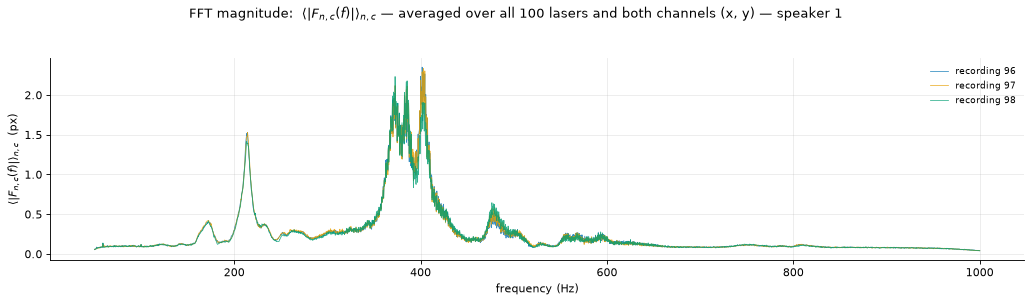

In [4]:
avg_figure('FFT magnitude')


**FFT magnitude — what we see.** This is *not* a featureless rolloff: the average |F| is dominated by resonances — a sharp peak at **214 Hz** and a tall cluster at **370–410 Hz**, with smaller structure near 480 and 560–600 Hz. All three recordings put the peaks at identical frequencies; the peak *heights* differ by a few percent (recording 98's main cluster is ~10% lower) — that is the per-capture gain $\gamma$ the model predicts. What linear magnitude hides: everything below ~0.3 px is squashed against zero.


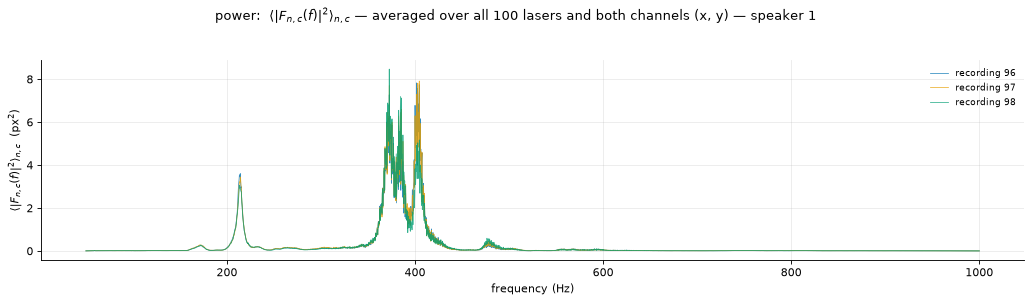

In [5]:
avg_figure('power')


**power — what we see.** The same curve squared. The 370–410 Hz cluster and 214 Hz now take *all* the visual budget; the 480/560 Hz structure barely survives and everything else is exactly zero to the eye. Squaring is a contrast knob: excellent for asking "what is THE dominant mode", terrible for seeing anything else.


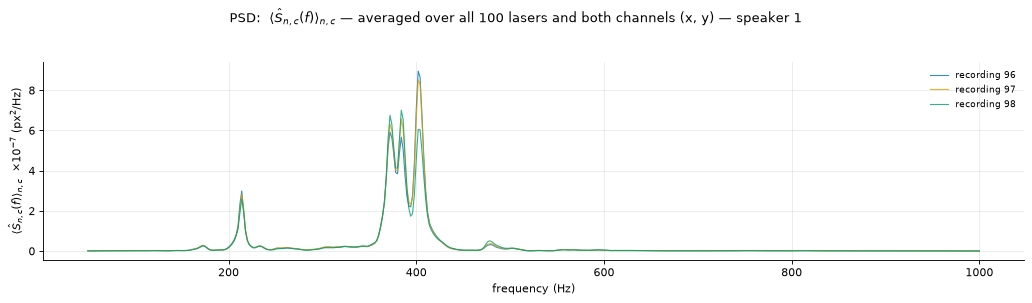

In [6]:
avg_figure('PSD')


**PSD — what we see.** Power after 11-segment averaging and per-Hz normalization (note the 10⁻⁷ px²/Hz scale): the same shape as power but *smooth* — the single-bin fuzz is averaged away (~11× lower estimator variance) at the cost of the 0.32 → 2 Hz grid. The small 480 Hz peak is now clean rather than buried in noise fuzz.


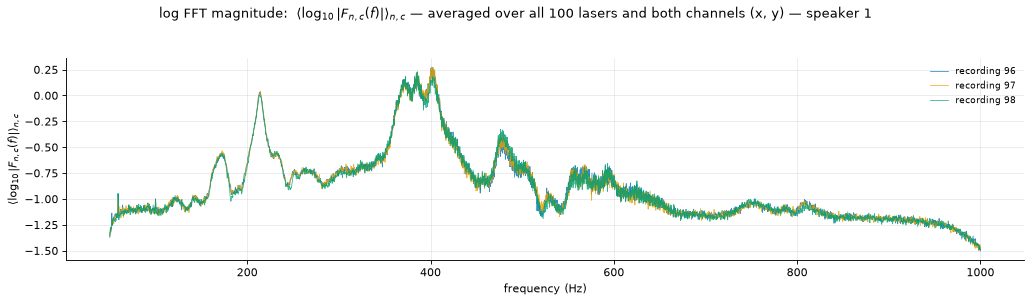

In [7]:
avg_figure('log FFT magnitude')


**log FFT magnitude — what we see.** The whole band becomes readable at once. Beyond the big peaks, secondary structure appears that linear space completely hid: peaks near 170, 230, 250, 480, 560, 600, 750 and 800 Hz, and the noise floor itself (≈10⁻¹·²–10⁻¹·⁵) with its gentle downward slope. All three recordings overlap to within a hair *everywhere* — including on the noise floor, which means even the "noise" is largely reproducible response, not measurement noise.


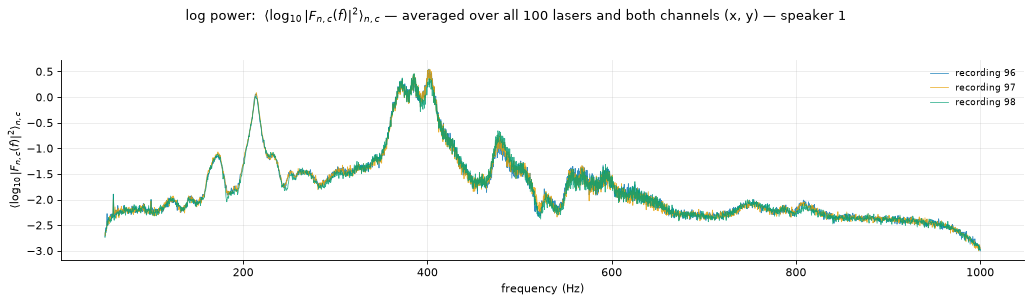

In [8]:
avg_figure('log power')


**log power — what we see.** Exactly the log-magnitude curve stretched ×2 ($\log_{10}|F|^2 = 2\log_{10}|F|$) — the same information, the same picture, different tick labels. Any scale-invariant analysis (correlation, ICC, a NN after normalization) treats these two identically; Part C confirms it numerically.


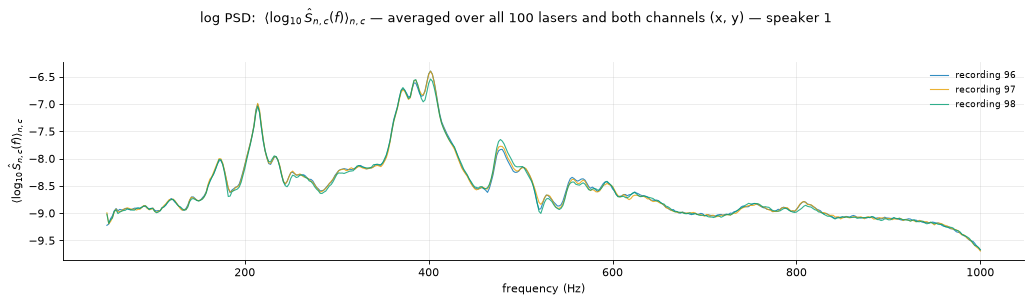

In [9]:
avg_figure('log PSD')


**log PSD — what we see.** The smooth version of log power on the 2 Hz grid — the best single "look at the data" view: peaks *and* the valleys between them (anti-resonance dips near 330 and 450 Hz) are both clean, and the three recordings are near-identical over the full 30 dB dynamic range.


## Part B — the same six signals, every laser shown

Averaging hides *where* on the box the signal lives. The heatmaps below un-average everything:

- **y-axis** = laser index (0–99, the 10×10 grid flattened row-major);
- **x-axis** = frequency (Hz);
- **color** = the signal;
- **top row** = x shifts, **bottom row** = y shifts;
- **columns** = the 3 recordings.

All 6 panels of a figure share one color scale, so brightness is directly comparable across recordings and channels. The test for "real" is the same as in Part A: structure must repeat across the three columns.


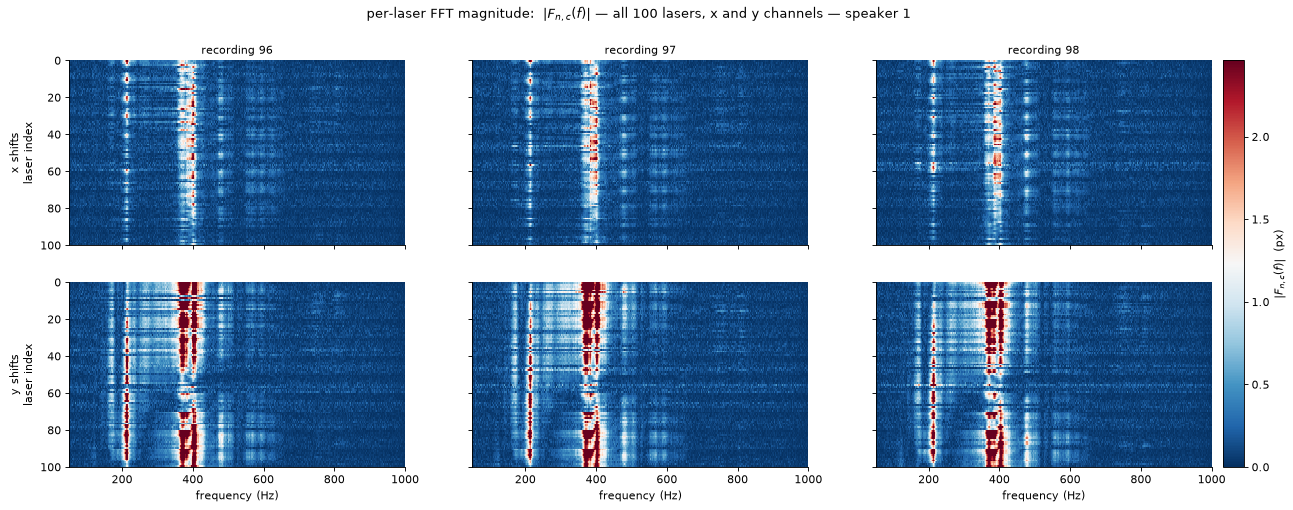

In [10]:
heat_figure('FFT magnitude')


**FFT magnitude, per laser — what we see.** The resonances become vertical stripes (214, 370–430 Hz) repeated identically in all three columns. Three new facts the average hid: (1) the **y channel responds far more than x** (bottom row saturates at 380–420 Hz); (2) horizontal banding = per-laser brightness $\beta_n$; (3) *within* a stripe, some lasers light up and others don't — that laser-to-laser pattern along a stripe is **mode-shape information**, the spatial signal an imaging model would use. Off-resonance everything is bottom-of-scale blue.


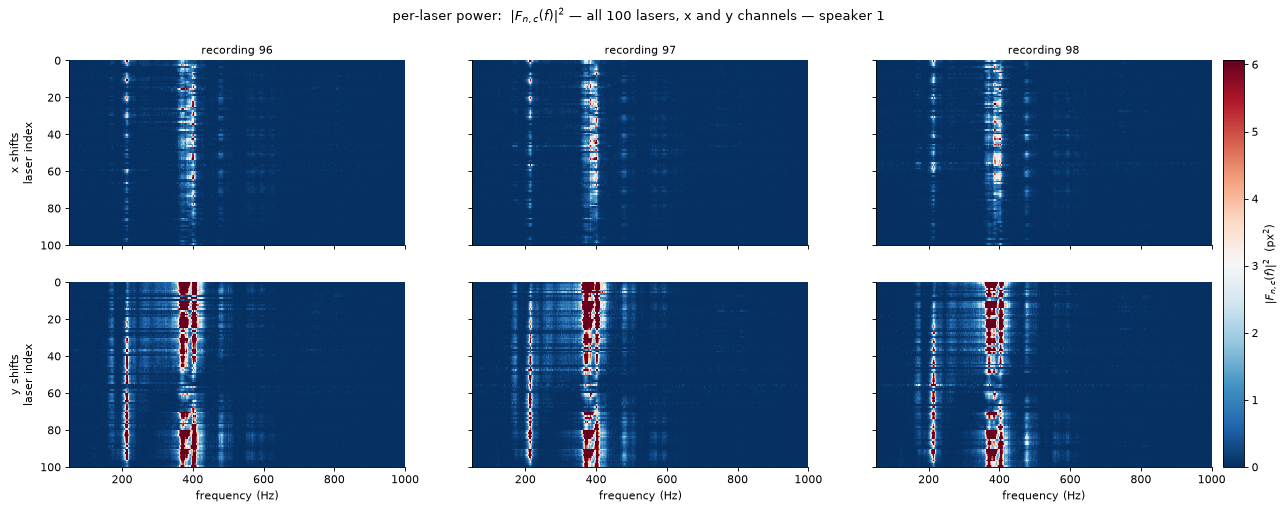

In [11]:
heat_figure('power')


**power, per laser — what we see.** Squaring pushes the contrast to the extreme: only the resonance stripes survive (deep red, clipped at the 99th-percentile color limit), and the y-channel 370–430 Hz stripe dominates everything. Useful as a mode detector, useless for the other 95% of the plane.


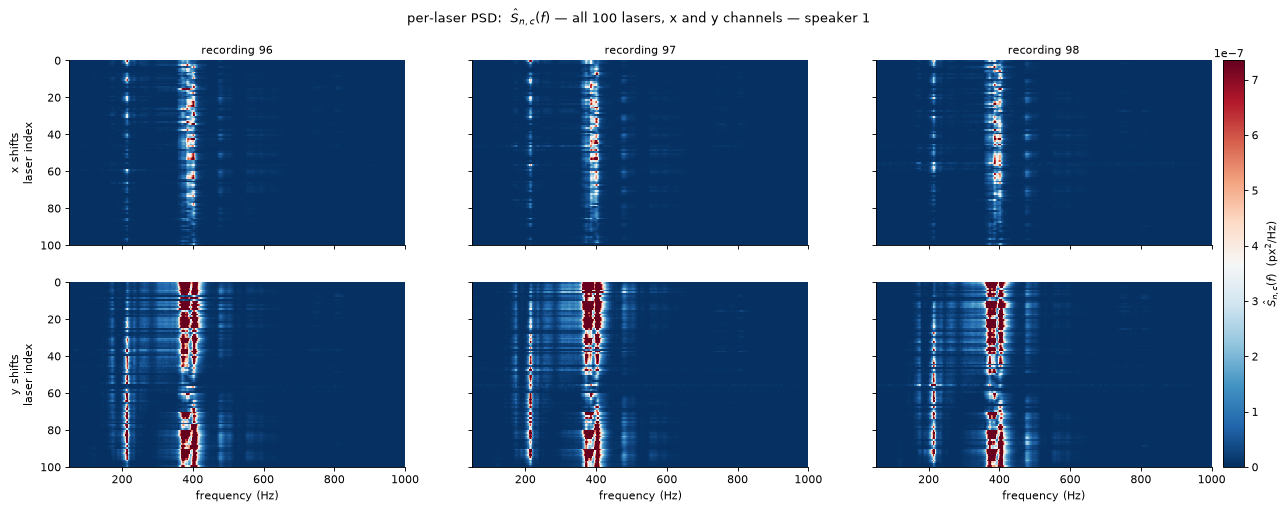

In [12]:
heat_figure('PSD')


**PSD, per laser — what we see.** Same layout as power but denoised by segment averaging: the stripes have smooth internal structure instead of speckle fuzz, and faint off-resonance texture (500–600 Hz, ~800 Hz) becomes visible that single-bin power buried in estimator noise.


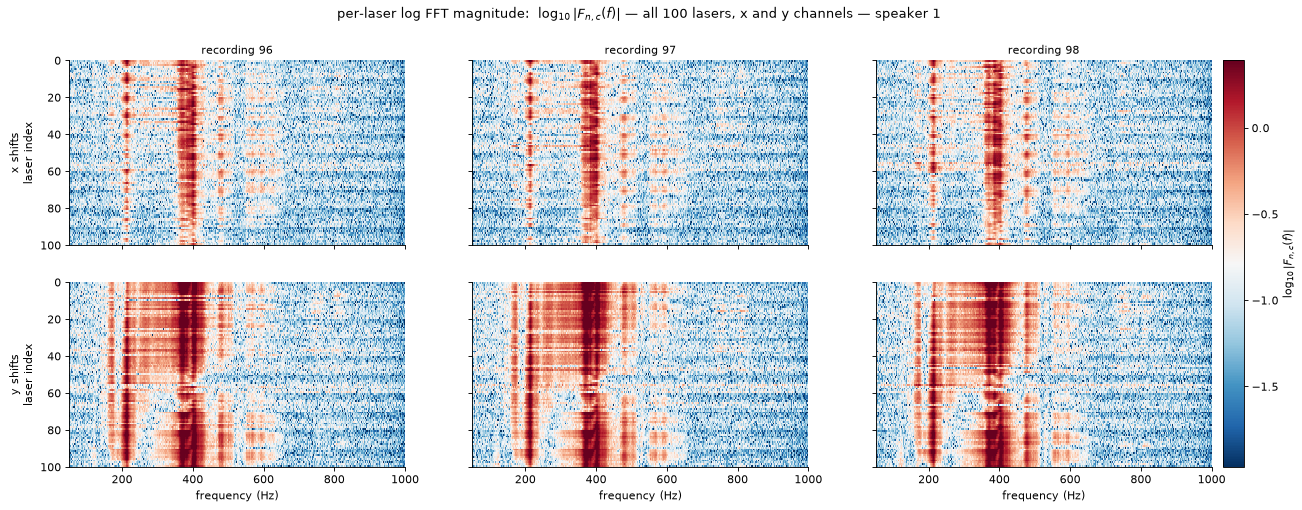

In [13]:
heat_figure('log FFT magnitude')


**log FFT magnitude, per laser — what we see.** The log transform spends color on *everything*: the resonance stripes, the per-laser horizontal bands ($\beta_n$), the anti-resonance gaps (note the dark vertical notch at ~420–440 Hz in the y channel, lasers 60–100), and weak stripes up to 800 Hz. The three columns agree in all of this fine structure — this is what "the recordings are identical up to per-capture offsets" looks like pixel by pixel.


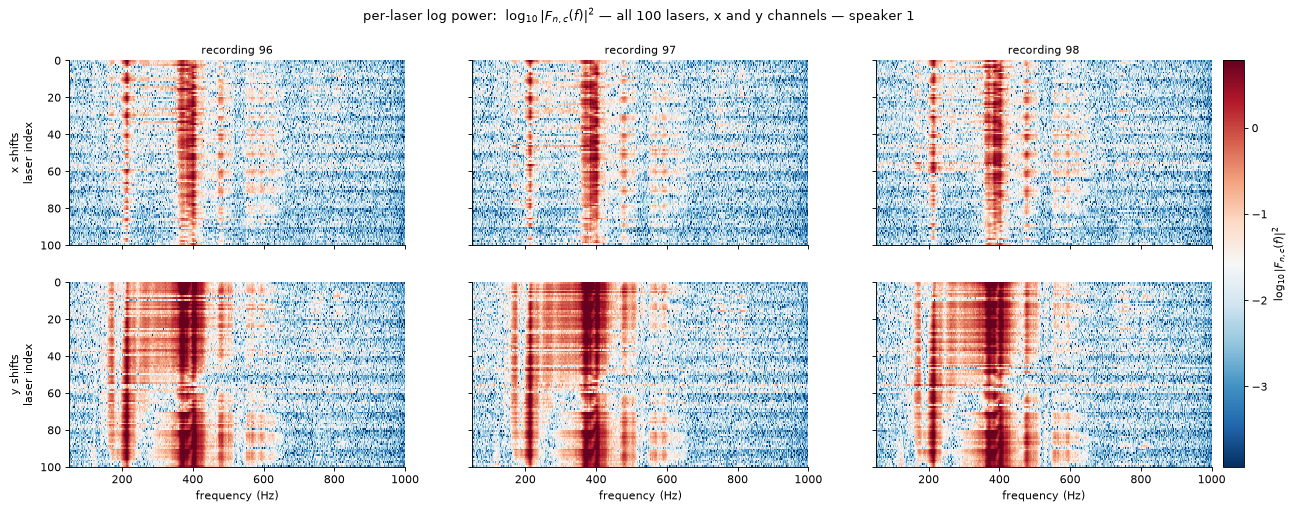

In [14]:
heat_figure('log power')


**log power, per laser — what we see.** Identical to log magnitude with the color scale doubled — compare panel-by-panel with the previous figure. One representation, two labels.


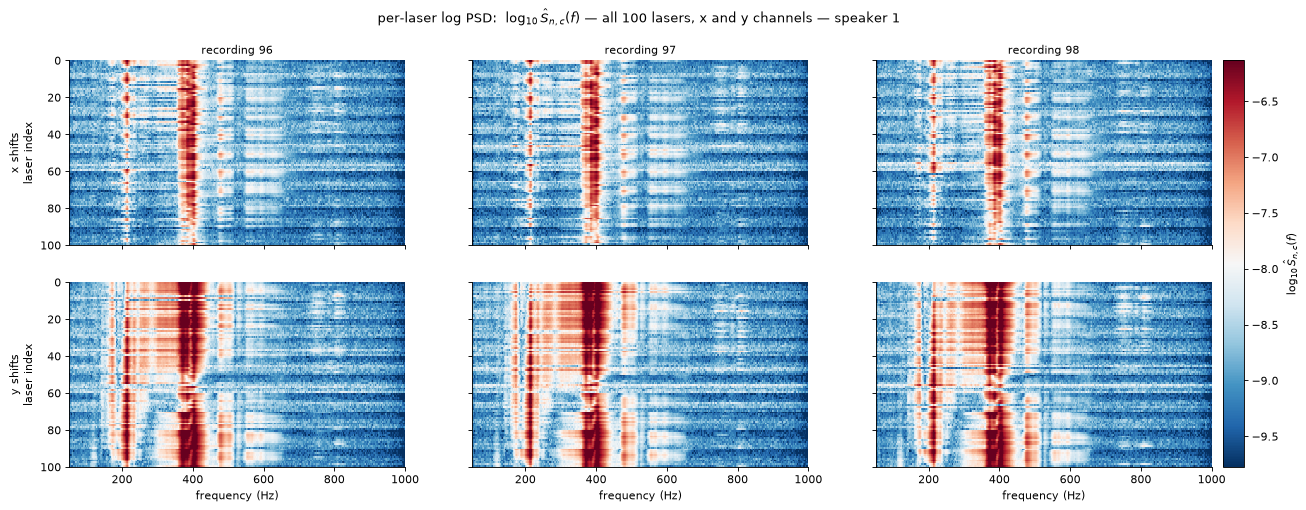

In [15]:
heat_figure('log PSD')


**log PSD, per laser — what we see.** The cleanest per-laser picture: log for readability *plus* Welch averaging for smoothness. Structure that is marginal in log |F| (the 700–850 Hz stripes, the laser-53 dark row) is unambiguous here and repeats across all three recordings. If one figure of this notebook were kept, it should be this one.


## Part C — how much *signal* is in each signal?

The three recordings should be identical **up to**: one overall gain per capture (loudness $\gamma$), one gain per laser per capture (speckle brightness $\beta_n$), and estimator noise. In log space those gains are *additive shifts*; in linear space they are multiplicative rescalings. Everything that survives beyond those shifts and the noise is signal.

Plain correlation between recordings is a fine *statistic* but has no built-in *baseline*: recordings of completely different scenes also correlate, because they share the low-frequency rolloff and the bright-laser structure. So we quantify signal three complementary ways:

1. **Correlation with a scene null** — the same Pearson r, but compared against *mismatched pairs* (same box, different speaker). Only the excess over the null is scene-specific signal.
2. **ICC (intraclass correlation)** — treat every (laser, channel, frequency) cell as a subject measured 3 times: $\mathrm{ICC} = \sigma^2_{\text{between cells}} / (\sigma^2_{\text{between}} + \sigma^2_{\text{repeat}})$ = *the fraction of the variance in one recording that would appear again if you re-recorded*. Caveat: it counts the generic tilt as signal, so read it together with (1).
3. **The estimator-noise floor** — theory fixes how similar two recordings *can* be: a single FFT bin of a diffuse response is complex-Gaussian, so its log-magnitude carries an irreducible $\sigma = \frac{\pi}{\sqrt{6}}\frac{10}{\ln 10} \approx 5.6$ dB of scatter; the 11-average Welch PSD shrinks this to $\sqrt{\psi'(11)}\cdot\frac{10}{\ln 10} \approx 1.3$ dB. If the measured repeat-to-repeat scatter sits at that floor, the recordings are as identical as the estimator allows.

One more fact that sharpens the question: magnitude, power, and their logs are **invertible transforms of one another — identical information** (their rank correlation is exactly 1). What differs between representations is how the variance is *arranged*: how much of the reproducible part is accessible to **linear** operations (means, correlations, normalization, a NN's first layer). That is what the numbers below measure.


In [16]:
# Part C needs mismatched scenes for the null: load the FFTs (and Welch PSDs) of ALL 8 speakers
import pandas as pd

ALL_SPK = list(range(1, 9))
F_all, PSD_all = {}, {}
for spk in ALL_SPK:
    for out in OUTPUTS:
        d = SAMPLES_DIR / f'{out * 8 + (spk - 1):06d}' / 'vibration'
        if not (d / '03_fft.npz').exists(): continue
        F_all[(spk, out)] = np.moveaxis(np.abs(load(d / '03_fft.npz')['fft'][0]), -1, 1)   # (L, C, fft bins) magnitude
        sh = np.load(d / '02_clean_shifts.npy')[0]
        _, P = sps.welch(np.moveaxis(sh, -1, 1), fs=FS, nperseg=NPERSEG, axis=-1)
        PSD_all[(spk, out)] = P[..., keep]

REPS = {  # representation -> per-capture array builder (from magnitude / PSD)
    'FFT magnitude':     lambda k: F_all[k],
    'power':             lambda k: F_all[k] ** 2,
    'PSD':               lambda k: PSD_all[k],
    'log FFT magnitude': lambda k: np.log10(F_all[k]),
    'log power':         lambda k: 2 * np.log10(F_all[k]),
    'log PSD':           lambda k: np.log10(PSD_all[k]),
}
print(f'loaded {len(F_all)} captures across {len(ALL_SPK)} speakers')


loaded 23 captures across 8 speakers


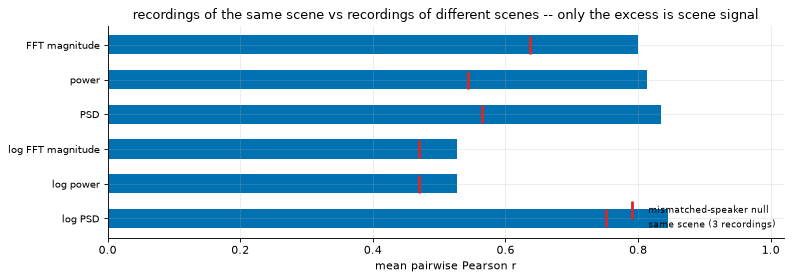

,r_same_scene,r_mismatched,excess
representation,,,
FFT magnitude,0.799,0.638,0.162
power,0.813,0.544,0.270
PSD,0.835,0.565,0.270
log FFT magnitude,0.527,0.470,0.057
log power,0.527,0.470,0.057
log PSD,0.846,0.752,0.093


In [17]:
# 1) correlation between recordings, against the mismatched-speaker null
import itertools

def pearson(u, v): return float(np.corrcoef(u.ravel(), v.ravel())[0, 1])

rows = []
for name, rep in REPS.items():
    same = [pearson(rep((spk, o1)), rep((spk, o2)))
            for spk in ALL_SPK for o1, o2 in itertools.combinations(OUTPUTS, 2)
            if (spk, o1) in F_all and (spk, o2) in F_all]
    null = [pearson(rep((s1, o1)), rep((s2, o2)))
            for s1, s2 in itertools.combinations(ALL_SPK, 2)
            for o1, o2 in [(OUTPUTS[0], OUTPUTS[1])]
            if (s1, o1) in F_all and (s2, o2) in F_all]
    rows.append(dict(representation=name, r_same_scene=np.mean(same), r_mismatched=np.mean(null),
                     excess=np.mean(same) - np.mean(null)))
corr_df = pd.DataFrame(rows).set_index('representation')

fig, ax = plt.subplots(figsize=(10, 3.6))
y = np.arange(len(corr_df))[::-1]
ax.barh(y, corr_df.r_same_scene, color='#0072B2', height=0.55, label='same scene (3 recordings)')
ax.plot(corr_df.r_mismatched, y, '|', color='#dc2626', ms=16, mew=2.5, label='mismatched-speaker null')
ax.set_yticks(y); ax.set_yticklabels(corr_df.index, fontsize=9)
ax.set_xlabel('mean pairwise Pearson r'); ax.set_xlim(0, 1.02)
ax.set_title('recordings of the same scene vs recordings of different scenes -- only the excess is scene signal')
ax.legend(frameon=False, fontsize=8, loc='lower right')
fig.tight_layout(); plt.show()
corr_df.round(3)


**What the correlation-with-null says.** Same-scene r is high for every representation — but so is the mismatched-scene null, which is exactly why raw correlation "doesn't seem like enough": most of any r between two spectra of this box is generic structure (tilt + bright lasers + the box's own modes responding to every speaker). The *excess* over the null is the scene-specific part: largest for **power and PSD (+0.27)** — the resonance peaks differ strongly between speakers, and squaring emphasizes them; moderate for FFT magnitude (+0.16); smallest for the raw log representations (+0.06–0.09), because log weights all cells equally, and most cells are near the (speaker-independent) noise floor. **Important**: this does *not* mean log is a worse feature — it means *uncentered* log correlation is a poor statistic. Notebook 53 showed that after removing the per-laser and per-frequency means, log space is where the scene signal is cleanest. Correlation is only as good as its null and its centering.


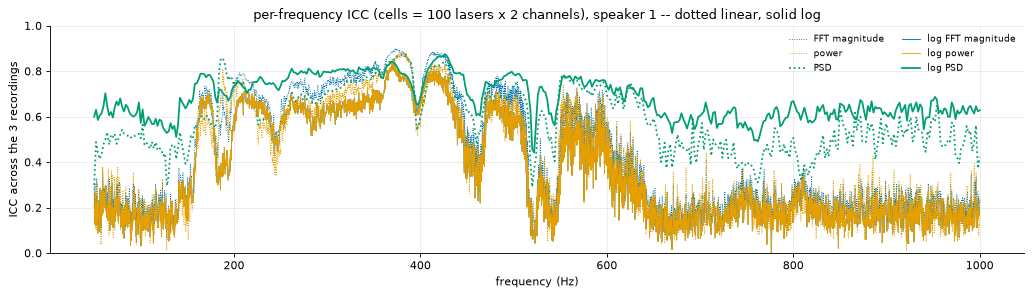

,ICC
representation,
FFT magnitude,0.913
power,0.861
PSD,0.860
log FFT magnitude,0.706
log power,0.706
log PSD,0.904


In [18]:
# 2) ICC: what fraction of one recording's variance would reproduce? overall, and resolved per frequency
def icc(stack):
    # stack: (n_recs, cells...) -> sigma_between / (sigma_between + sigma_within), bias-corrected
    m = stack.shape[0]
    within = stack.var(axis=0, ddof=1).mean()
    between = max(stack.mean(axis=0).var() - within / m, 0.0)
    return between / (between + within)

rows, icc_f = [], {}
for name, rep in REPS.items():
    stack = np.stack([rep((SPEAKER, o)) for o in OUTPUTS if (SPEAKER, o) in F_all])   # (recs, L, C, bins)
    rows.append(dict(representation=name, ICC=icc(stack)))
    icc_f[name] = np.array([icc(stack[..., i]) for i in range(stack.shape[-1])])
icc_df = pd.DataFrame(rows).set_index('representation')

fig, ax = plt.subplots(figsize=(13, 3.8))
for (name, curve), c in zip(icc_f.items(), ['#0072B2', '#E69F00', '#009E73', '#0072B2', '#E69F00', '#009E73']):
    grid = freqs if len(curve) == len(freqs) else FW
    ax.plot(grid, curve, color=c, lw=0.8 if len(curve) == len(freqs) else 1.6,
            ls='-' if 'log' in name else ':', label=name)
ax.set_xlabel('frequency (Hz)'); ax.set_ylabel('ICC across the 3 recordings'); ax.set_ylim(0, 1)
ax.set_title(f'per-frequency ICC (cells = 100 lasers x 2 channels), speaker {SPEAKER} -- dotted linear, solid log')
ax.legend(frameon=False, fontsize=8, ncol=2)
fig.tight_layout(); plt.show()
icc_df.round(3)


**What the ICC says.** Overall ICC (fraction of one recording's variance that reproduces): FFT magnitude 0.91, power/PSD 0.86, log PSD 0.90, log |F| ≈ log power 0.71. The linear numbers are flattered by the giant resonance cells dominating the between-cell variance; the log numbers are noise-limited per single 0.32 Hz bin. The per-frequency curve is the more honest view: **reproducibility concentrates at the modal bands** (ICC → 0.8–0.9 near 200 and 350–450 Hz for every representation) and collapses to ~0.2 off-resonance for all single-bin representations — while **log PSD holds ICC ≈ 0.6–0.8 across the whole band**, because segment averaging suppresses exactly the estimator noise that kills the others. That is the quantitative version of "log PSD is the best single view".


In [19]:
# 3) repeat-to-repeat scatter vs the theoretical estimator floor (in dB, per single cell)
from scipy.special import polygamma

DB = 10 / np.log(10)
floors = {'log FFT magnitude': np.pi / np.sqrt(6) * DB / 2,         # half the log-power floor (log|F| = log|F|^2 / 2) ~2.8 dB
          'log power':         np.pi / np.sqrt(6) * DB,             # std of 10*log10 of an Exp-distributed power ~5.6 dB
          'log PSD':           float(np.sqrt(polygamma(1, 11))) * DB}  # chi2 with ~11 averages ~1.3 dB

rows = []
for name in ['log FFT magnitude', 'log power', 'log PSD']:
    stack = np.stack([REPS[name]((SPEAKER, o)) for o in OUTPUTS if (SPEAKER, o) in F_all])
    per_cell_std_db = stack.std(axis=0, ddof=1) * 10   # log10 -> dB(power) units: 10*log10
    rows.append(dict(representation=name,
                     median_repeat_std_dB=float(np.median(per_cell_std_db)),
                     theory_floor_dB=floors[name]))
floor_df = pd.DataFrame(rows).set_index('representation')
floor_df['ratio'] = floor_df.median_repeat_std_dB / floor_df.theory_floor_dB
floor_df.round(2)


,median_repeat_std_dB,theory_floor_dB,ratio
representation,,,
log FFT magnitude,1.81,2.79,0.65
log power,3.62,5.57,0.65
log PSD,1.68,1.34,1.26


**What the estimator floor says.** Two punchlines. (1) The single-bin repeat scatter (1.81 dB for log |F|) is only **0.65× the diffuse-field floor** (2.79 dB): if the box response were speckle-chaos, recordings could not agree this well — the sub-floor scatter is direct evidence that most bins are dominated by a *deterministic, phase-stable* response (consistent with notebook 53's finding that even cross-recording phase survives on this dataset). (2) Log PSD sits **1.26× above its own floor** (1.68 vs 1.34 dB): once Welch averaging shrinks estimator noise to ~1.3 dB, the residual ~1 dB of real recording-to-recording drift (the $\gamma$, $\beta_n$ gains) becomes visible above it. So: FFT bins are estimator-noise-limited, PSD bins are drift-limited — which is exactly the regime where per-capture normalization (log-space centering) pays off.


## Part D — phase

Everything so far used magnitude. At a single (laser, frequency) cell the FFT is one complex number $F = |F|\,e^{i\varphi}$ — the phase $\varphi$ says *when* in the cycle that laser moves, relative to the capture's time origin. Since captures are triggered together with the audio, a deterministic, trigger-stable response means $\varphi$ should **repeat across recordings** (notebook 53 established this at the population level; here we watch it happen at one laser).

Four views, from most physical to most abstract:

1. **time domain, x** — the shift signal bandpassed around a chosen mode: if phase is locked, the three recordings' oscillations lie *on top of each other*, cycle for cycle;
2. **time domain, y** — same for the y channel;
3. **Cartesian** — $\mathrm{Re}\,F$ vs $\mathrm{Im}\,F$ through the band around the mode: a resonance sweeps out a circle (the classic Nyquist picture); locked phase means the three circles coincide, not just match in size;
4. **polar** — phase angle vs frequency (radius) over the whole band: locked phase means the three recordings paint the *same* angular pattern.

Pick the cell here:


In [20]:
FREQ = 214.0        # Hz -- pick a strong mode (speaker 1: 214, or the 370-410 cluster)
BAND = 20.0         # half-width (Hz) of the band used in the Cartesian view
LASER = None        # None -> automatically use the laser with the largest |F| at FREQ

fi = int(np.argmin(np.abs(freqs - FREQ)))
if LASER is None:
    LASER = int(np.abs(np.stack([F[o][:, fi, :] for o in RECS])).mean(axis=(0, 2)).argmax())
print(f'FREQ = {FREQ} Hz (fft bin {fi}), LASER = {LASER}')


FREQ = 214.0 Hz (fft bin 508), LASER = 60


In [21]:
def narrowband_traces(ch):
    # bandpass the raw shift signal +-5 Hz around FREQ and overlay the three recordings
    ci = 'xy'.index(ch)
    sos = sps.butter(4, [FREQ - 5, FREQ + 5], 'bandpass', fs=FS, output='sos')
    zs = {out: sps.sosfiltfilt(sos, np.load(SAMPLES_DIR / f'{out * 8 + (SPEAKER - 1):06d}' / 'vibration/02_clean_shifts.npy')[0][LASER, :, ci])
          for out in RECS}
    t = np.arange(len(zs[RECS[0]])) / FS
    tpk = t[np.argmax(np.abs(zs[RECS[0]]))]
    fig, axes = plt.subplots(1, 2, figsize=(16, 3.2), width_ratios=[2, 1])
    for out in RECS:
        axes[0].plot(t, zs[out], color=OUT_COLORS[out], lw=0.6, label=f'recording {out}')
        axes[1].plot(t, zs[out], color=OUT_COLORS[out], lw=1.4)
    axes[1].set_xlim(tpk - 4 / FREQ, tpk + 4 / FREQ)
    axes[0].axvspan(tpk - 4 / FREQ, tpk + 4 / FREQ, color='#9ca3af', alpha=0.3)
    axes[0].set_xlabel('time (s)'); axes[1].set_xlabel('time (s)'); axes[0].set_ylabel(f'{ch} shift, bandpassed (px)')
    axes[0].set_title(f'full capture (gray band = zoom)', fontsize=10); axes[1].set_title('zoom: 8 cycles', fontsize=10)
    axes[0].legend(frameon=False, fontsize=8)
    fig.suptitle(f'laser {LASER}, {ch} channel, bandpassed {FREQ:.0f}$\pm$5 Hz -- do the oscillations line up cycle for cycle?', y=1.03)
    fig.tight_layout(); plt.show()


<>:18: SyntaxWarning: invalid escape sequence '\p'
<>:18: SyntaxWarning: invalid escape sequence '\p'
C:\Users\eitanturok\AppData\Local\Temp\ipykernel_9964\515649717.py:18: SyntaxWarning: invalid escape sequence '\p'
  fig.suptitle(f'laser {LASER}, {ch} channel, bandpassed {FREQ:.0f}$\pm$5 Hz -- do the oscillations line up cycle for cycle?', y=1.03)


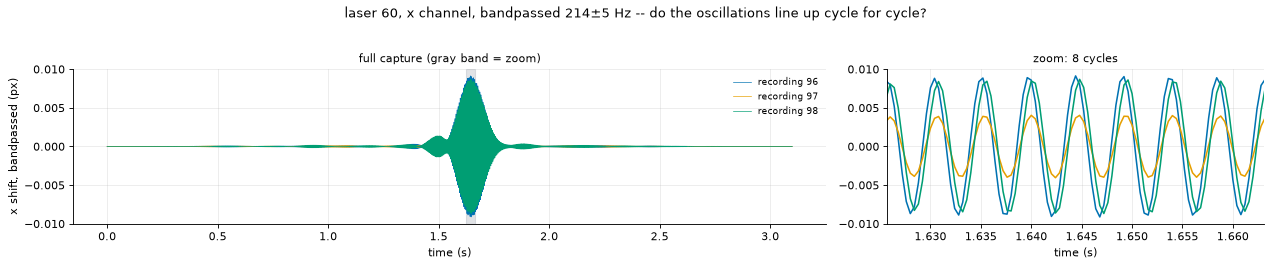

In [22]:
narrowband_traces('x')


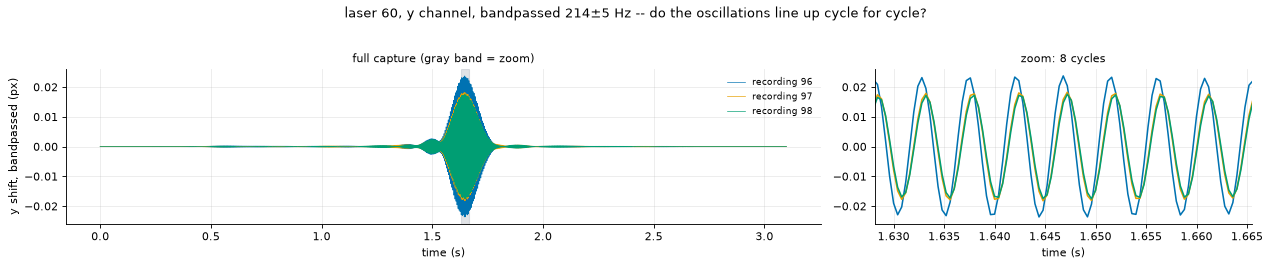

In [23]:
narrowband_traces('y')


_phase-time observations placeholder_


<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
C:\Users\eitanturok\AppData\Local\Temp\ipykernel_9964\3590932935.py:12: SyntaxWarning: invalid escape sequence '\p'
  fig.suptitle(f'Cartesian view: F(f) for f in {FREQ:.0f}$\pm${BAND:.0f} Hz, laser {LASER} '


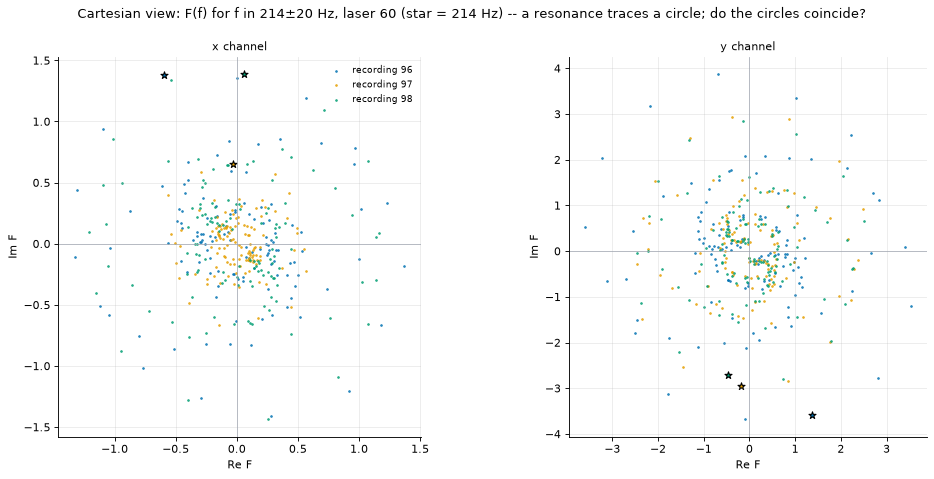

In [36]:
band = (freqs >= FREQ - BAND) & (freqs <= FREQ + BAND)
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ci, (ax, ch) in enumerate(zip(axes, 'xy')):
    for out in RECS:
        z = F[out][LASER, band, ci]
        ax.scatter(z.real, z.imag, marker='o', color=OUT_COLORS[out], lw=0.8, alpha=0.75, s=2.5, label=f'recording {out}')
        zf = F[out][LASER, fi, ci]
        ax.scatter(zf.real, zf.imag, marker='*', color=OUT_COLORS[out], edgecolor='k', s=44)
    ax.axhline(0, color='#9ca3af', lw=0.6); ax.axvline(0, color='#9ca3af', lw=0.6)
    ax.set_aspect('equal'); ax.set_xlabel('Re F'); ax.set_ylabel('Im F'); ax.set_title(f'{ch} channel', fontsize=10)
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle(f'Cartesian view: F(f) for f in {FREQ:.0f}$\pm${BAND:.0f} Hz, laser {LASER} '
             f'(star = {FREQ:.0f} Hz) -- a resonance traces a circle; do the circles coincide?', y=0.99)
fig.tight_layout(); plt.show()


_cartesian observations placeholder_


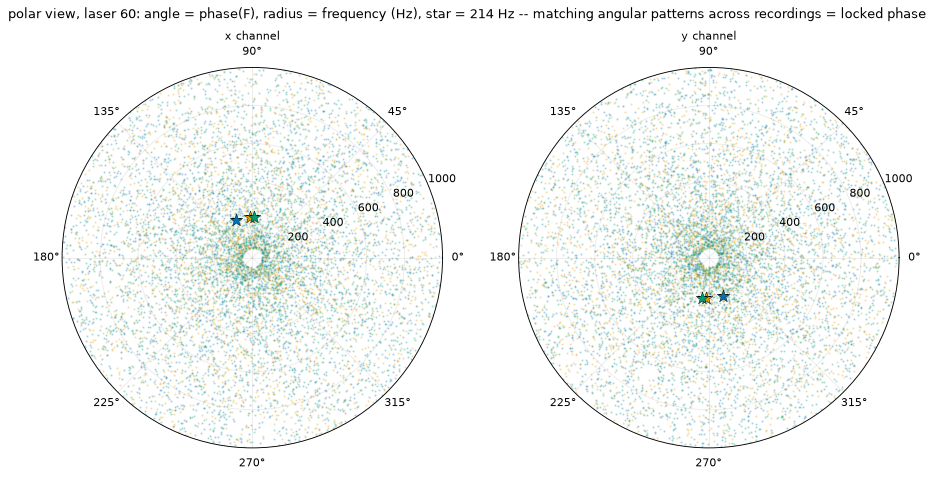

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.2), subplot_kw=dict(projection='polar'))
for ci, (ax, ch) in enumerate(zip(axes, 'xy')):
    for out in RECS:
        ax.scatter(np.angle(F[out][LASER, :, ci]), freqs, s=1.2, alpha=0.2, color=OUT_COLORS[out])
        ax.scatter(np.angle(F[out][LASER, fi, ci]), FREQ, marker='*', s=140, color=OUT_COLORS[out],
                   edgecolor='k', linewidth=0.4, zorder=5)
    ax.set_title(f'{ch} channel', fontsize=10)
    ax.set_rlim(0, 1000)
fig.suptitle(f'polar view, laser {LASER}: angle = phase(F), radius = frequency (Hz), star = {FREQ:.0f} Hz -- '
             'matching angular patterns across recordings = locked phase', y=1.0)
plt.show()


_polar observations placeholder_


## Takeaways

1. **One box, six views, one dataset-wide conclusion**: the three recordings are the same measurement up to a per-capture gain, per-laser gains, and estimator noise — visible in every figure and quantified in Part C.
2. **The six signals are one signal**: magnitude/power/log are invertible transforms (log power ≡ 2·log magnitude, exactly); PSD is power with 11-segment averaging. They differ only in how they *arrange* variance — i.e., which parts a linear operation (mean, correlation, normalization layer) can access.
3. **Linear representations spotlight the modes** (214, 370–430 Hz stripes, y ≫ x) and hide everything else; **log representations show the full structure** including the reproducible "noise floor"; **log PSD is the best single view and the most reproducible per cell** (ICC ≈ 0.6–0.8 band-wide).
4. **Correlation alone overstates signal** — mismatched scenes correlate 0.47–0.75. Always report the excess over a matched null. By that yardstick the scene-specific signal is strongest in power/PSD (+0.27) *before* centering, and (from notebook 53) in centered log space after.
5. **The recordings agree better than speckle chaos allows** (0.65× the diffuse floor per FFT bin): the response is deterministic and phase-stable on this dataset. PSD-level agreement is limited by ~1 dB of real per-capture gain drift — the thing log-space centering removes.
6. Next: repeat Part C per speaker and, once object recordings exist, use the same three metrics (null-referenced r, ICC, floor ratio) to measure how much *object* signal each representation carries.
